In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
a = np.load("test_CO/RDM_state_1.npy")
X = np.loadtxt("test_CO/output_SD_RDM_state1_2")
#calculation made in pySCF :
np.shape(X)

(7, 3)

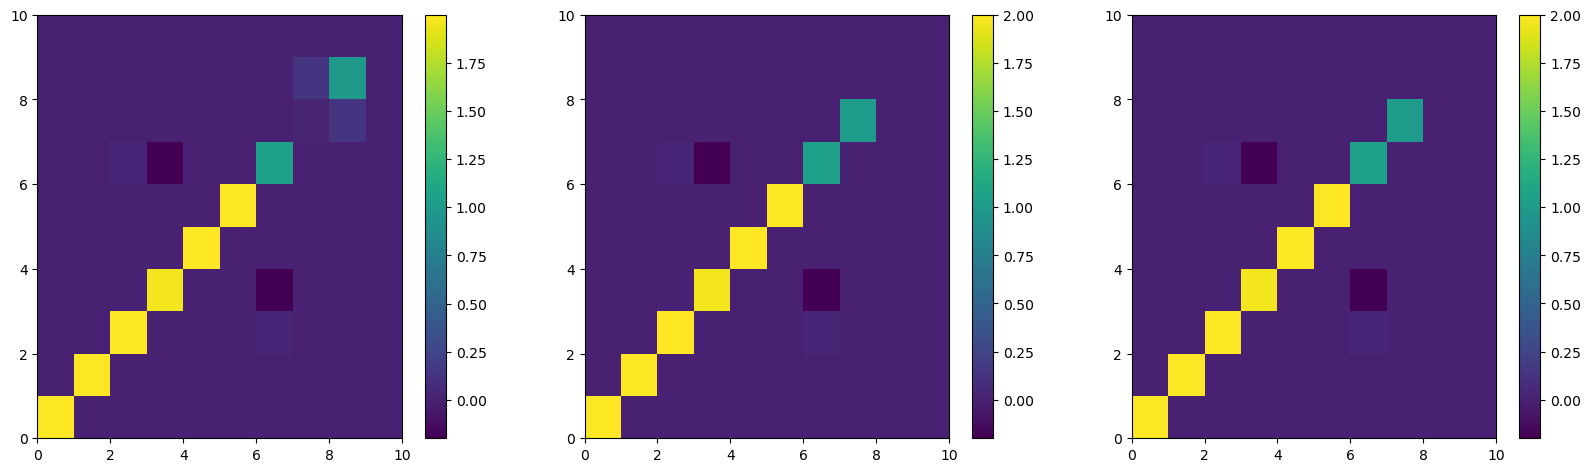

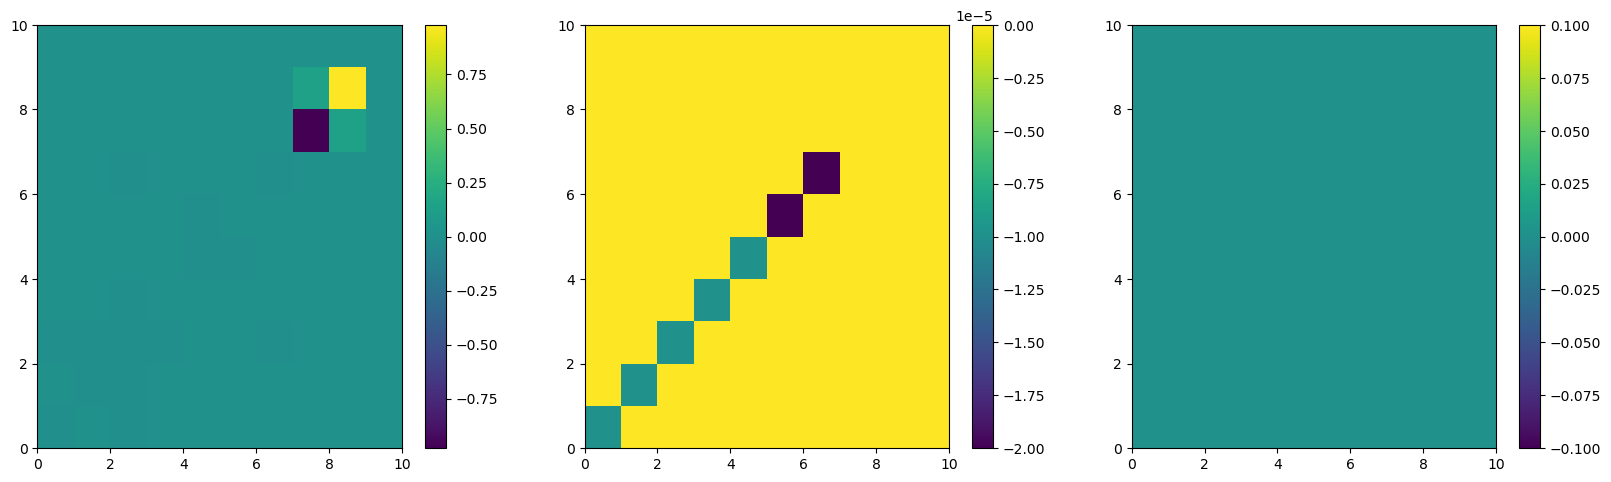

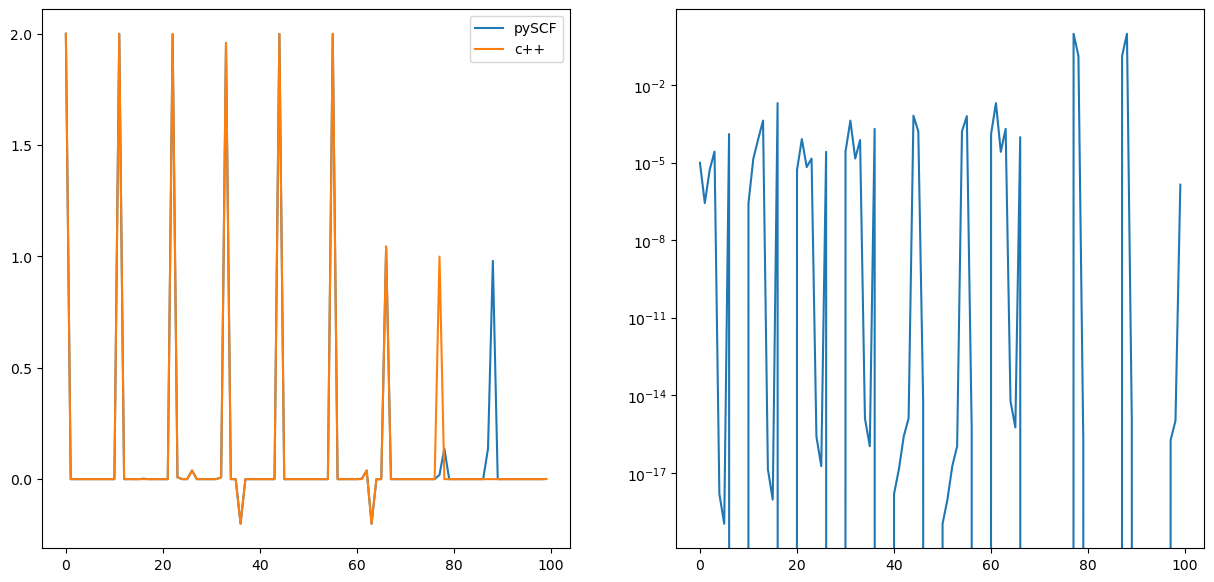

In [130]:
RDM_pySCF = np.load("test_CO/pySCF/RDM_state_2.npy")
#nofunc_a = np.load("test_CO/pySCF/no_func_RDM_state_1.npy")
RDM_X = np.loadtxt("test_CO/output_pySCF_RDM_state_1_2")
RDM_SD = np.loadtxt("test_CO/output_pySCF_RDM_state_1")

#plot RDM matrices
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(RDM_pySCF)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM_X[0:10])
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM_SD[0:10])
plt.colorbar(plot3)
plt.show()

#compare RDM matrices with the one from the SD method 
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(RDM_pySCF-RDM_SD[0:10])
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM_X[0:10]-RDM_SD[0:10])
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM_SD[0:10]-RDM_SD[0:10])
plt.colorbar(plot3)
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(15,7))#,subplot_kw={"projection": "3d"})
ax[0].plot(RDM_pySCF.flatten(),label="pySCF")
ax[0].plot(RDM_SD.flatten()[0:100],label="c++")
ax[0].legend()
plot2 = ax[1].plot(np.abs(RDM_SD.flatten()[0:100]-RDM_pySCF.flatten()[0:100]))
plt.yscale('log')
plt.show()

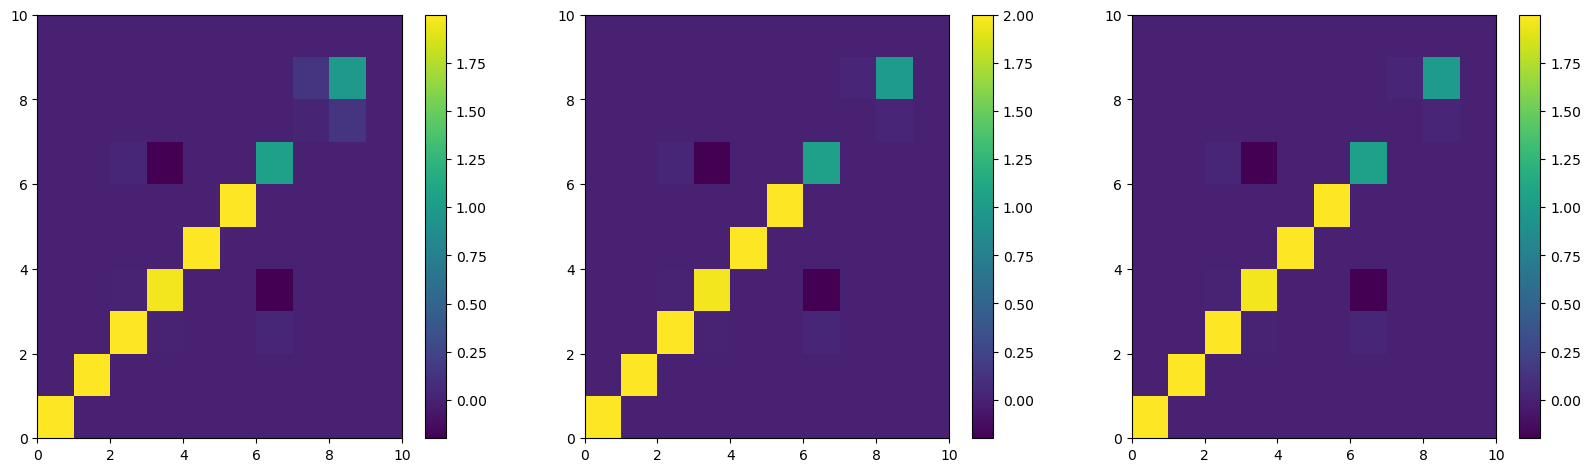

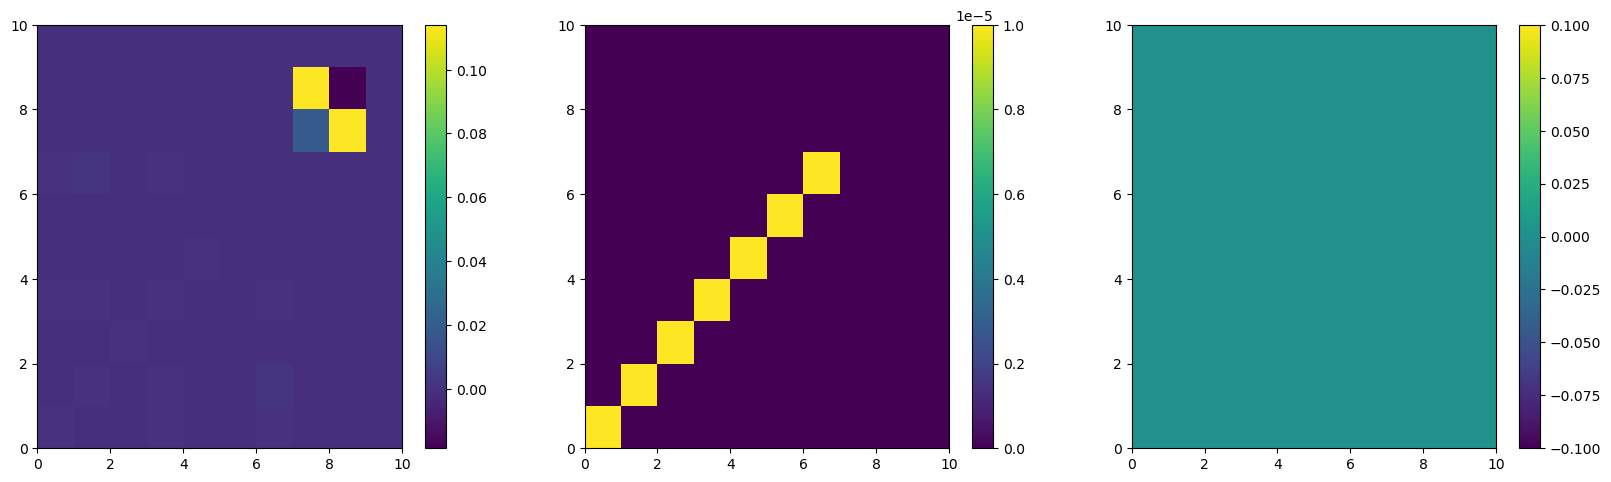

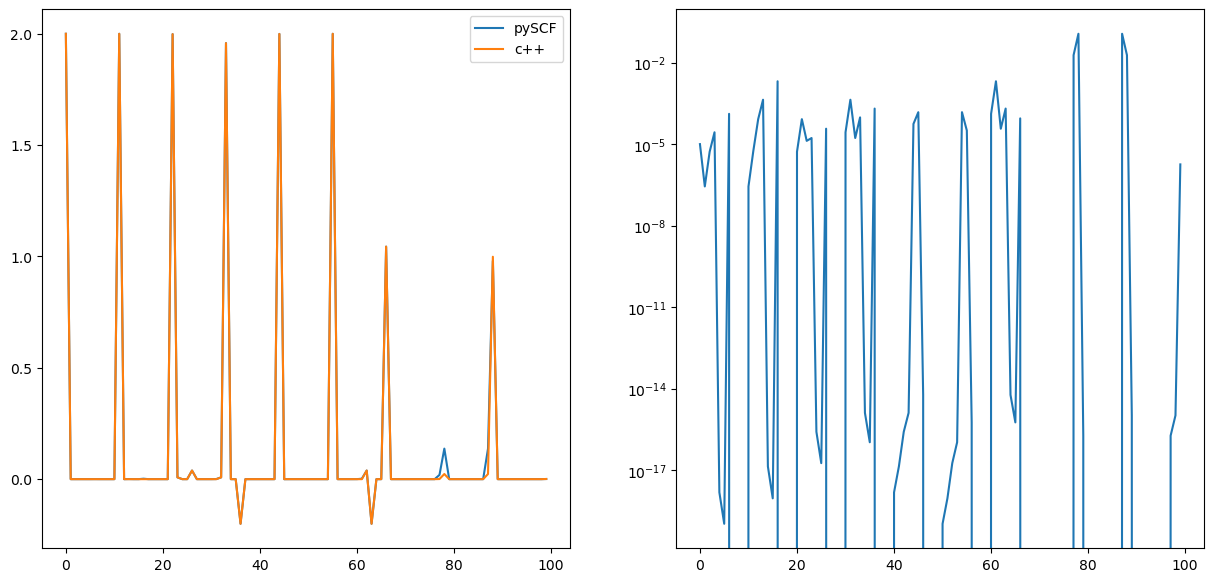

In [141]:
RDM_pySCF = np.load("test_CO/pySCF/RDM_state_2.npy")
#nofunc_a = np.load("test_CO/pySCF/no_func_RDM_state_1.npy")
RDM_X = np.loadtxt("test_CO/etats_superieures/output_SD_RDM_state_1_2")
RDM_SD = np.loadtxt("test_CO/etats_superieures/output_SD_RDM_state_1")

#plot RDM matrices
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(RDM_pySCF)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM_X[0:10])
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM_SD[0:10])
plt.colorbar(plot3)
plt.show()

#compare RDM matrices with the one from the SD method 
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(RDM_pySCF-RDM_SD[0:10])
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM_X[0:10]-RDM_SD[0:10])
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM_SD[0:10]-RDM_SD[0:10])
plt.colorbar(plot3)
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(15,7))#,subplot_kw={"projection": "3d"})
ax[0].plot(RDM_pySCF.flatten(),label="pySCF")
ax[0].plot(RDM_SD.flatten()[0:100],label="c++")
ax[0].legend()
plot2 = ax[1].plot(np.abs(RDM_SD.flatten()[0:100]-RDM_pySCF.flatten()[0:100]))
plt.yscale('log')
plt.show()

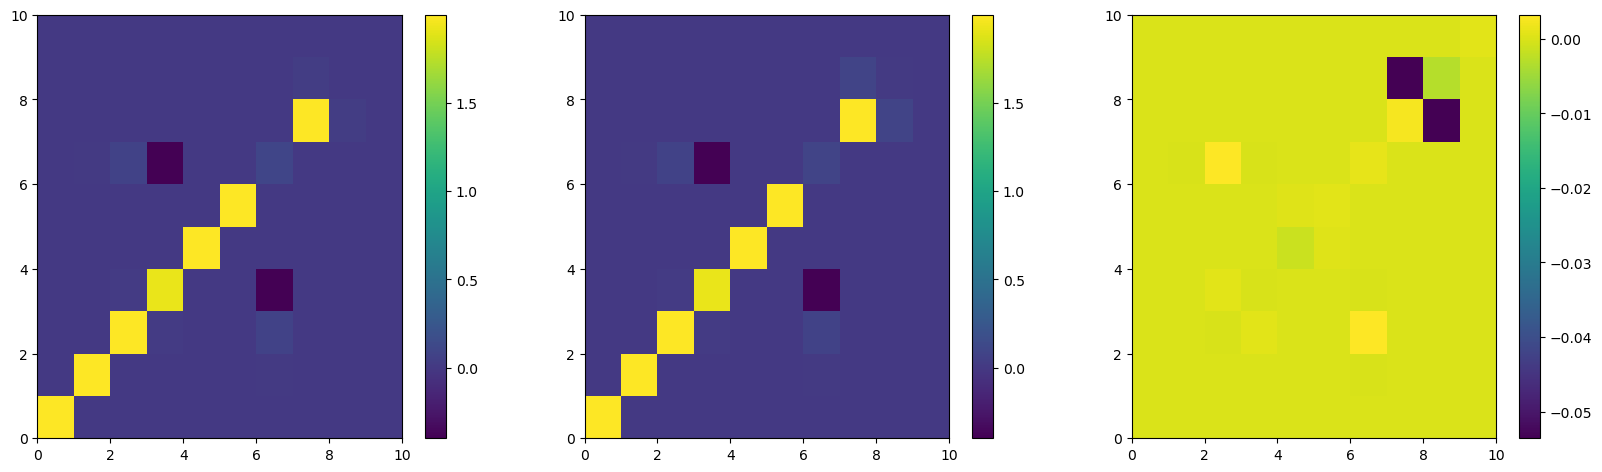

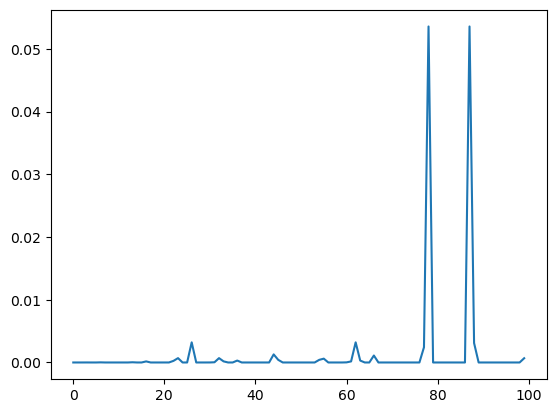

In [80]:
pyRDM = np.load("test_CO/pySCF/RDM_state_1.npy")
nofunc_pyRDM = np.load("test_CO/pySCF/no_func_RDM_state_1.npy")

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(pyRDM[0:10])
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(nofunc_pyRDM[0:10])
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(pyRDM[0:10]-nofunc_pyRDM[0:10])
plt.colorbar(plot3)
plt.show()

plt.plot(np.abs(pyRDM.flatten()-nofunc_pyRDM.flatten()))

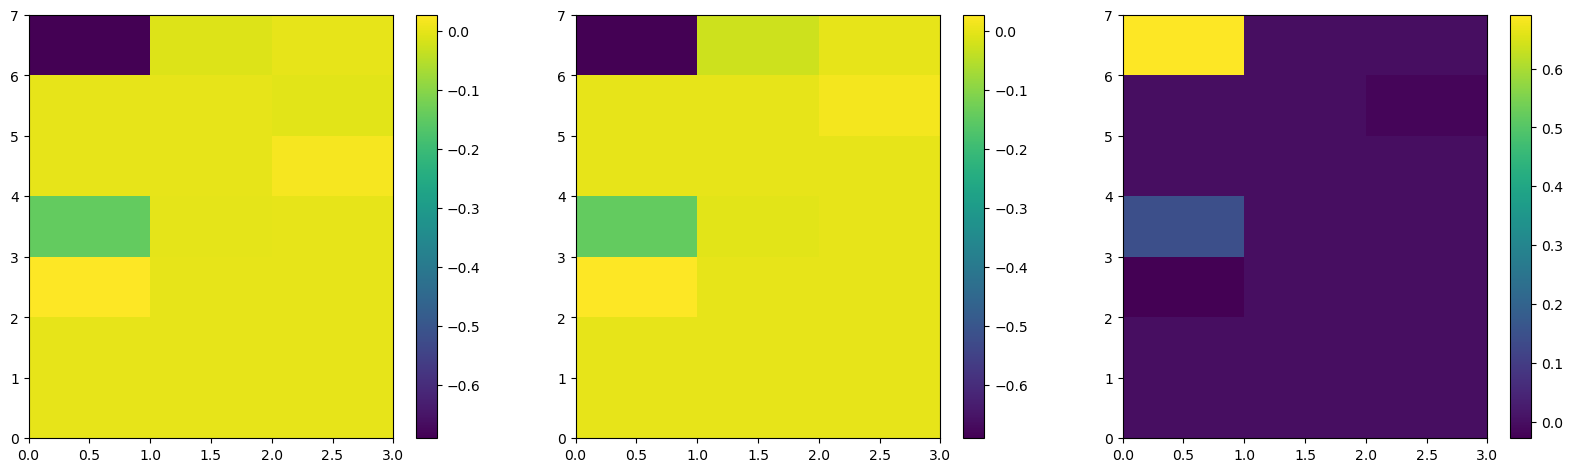

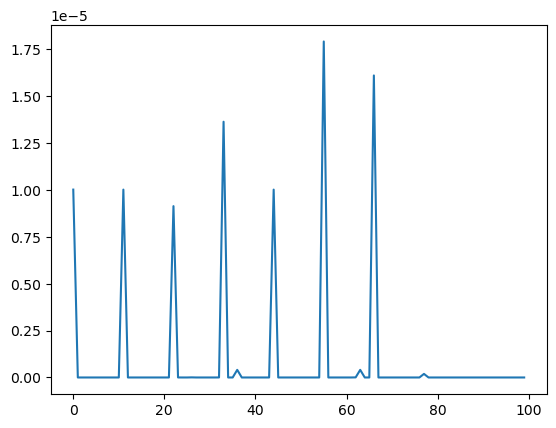

In [115]:
py_X = np.load("test_CO/pySCF/X_state_1.npy")
nofunc_py_X = np.load("test_CO/pySCF/no_func_X_state_1.npy")
SD_X = np.loadtxt("test_CO/output_SD_RDM_state_1_X")

gamma = np.loadtxt("test_CO/output_SD_RDM_state_1")

#calculation made in pySCF :
nocc,nvir = np.shape(SD_X)
nmo = nocc+nvir

#norm = np.sqrt(np.sum(X ** 2))
#print(norm)
#X = X / norm                           # shape (nocc, nvir)

SD_RDM = np.zeros((nmo, nmo))

# Occupied-occupied block: ground-state occ - hole depletion
SD_RDM[:nocc, :nocc] = 2.0 * np.eye(nocc) - 2.0 * (SD_X @ SD_X.T)

# Virtual-virtual block: particle gain
SD_RDM[nocc:, nocc:] = 2.0 * (SD_X.T @ SD_X)

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(py_X)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(nofunc_py_X)
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(SD_X)
plt.colorbar(plot3)
plt.show()


plt.plot(np.abs(SD_RDM.flatten()-gamma.flatten()[0:100]))

In [123]:
py_X = np.load("test_CO/pySCF/X_state_1.npy")
nofunc_py_X = np.load("test_CO/pySCF/no_func_X_state_1.npy")
SD_X = np.loadtxt("test_CO/output_pySCF_RDM_state_1_X")

a = np.abs(py_X)
print('pySCF with functionnal blyp')
for i in range(10):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/3+1))}->{pos%3+8} with coef {val:.5f}')
    a[int(np.floor(pos/3)),pos%3]=0
print("")

a = np.abs(nofunc_py_X)
print('pySCF with no functionnal')
for i in range(10):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/3+1))}->{pos%3+8} with coef {val:.5f}')
    a[int(np.floor(pos/3)),pos%3]=0
print("")

a = np.abs(SD_X)
print('from cdftt')
for i in range(10):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/3+1))}->{pos%3+8} with coef {val:.5f}')
    a[int(np.floor(pos/3)),pos%3]=0
print("")

with np.printoptions(precision=3,suppress=True):
    print(py_X)
    print(nofunc_py_X)
    print(SD_X)

pySCF with functionnal blyp
transition 7->9 with coef 0.69131
transition 4->9 with coef 0.14476
transition 3->9 with coef 0.02799
transition 6->10 with coef 0.01864
transition 7->8 with coef 0.00228
transition 2->9 with coef 0.00148
transition 5->10 with coef 0.00092
transition 4->8 with coef 0.00048
transition 1->9 with coef 0.00009
transition 3->8 with coef 0.00009

pySCF with no functionnal
transition 7->8 with coef 0.69089
transition 4->8 with coef 0.14448
transition 7->9 with coef 0.02925
transition 3->8 with coef 0.02680
transition 6->10 with coef 0.01334
transition 4->9 with coef 0.00612
transition 2->8 with coef 0.00154
transition 3->9 with coef 0.00113
transition 5->10 with coef 0.00105
transition 1->8 with coef 0.00009

from cdftt
transition 7->8 with coef 0.69128
transition 4->8 with coef 0.14492
transition 3->8 with coef 0.02801
transition 6->10 with coef 0.01868
transition 1->8 with coef 0.00000
transition 1->8 with coef 0.00000
transition 1->8 with coef 0.00000
transition

In [102]:
# a, nofunc_a, dm1, gamma
# pySCF, py SCF sans finctionnelle, c++ a la manière de pySCF, c++

b = a
print(np.sum(np.diag(b)[0:7]))
print(np.sum(np.diag(b)[7:10]))

b = nofunc_a
print(np.sum(np.diag(b)[0:7]))
print(np.sum(np.diag(b)[7:10]))

b = dm1
print(np.sum(np.diag(b)[0:7]))
print(np.sum(np.diag(b)[7:10]))

b = gamma
print(np.sum(np.diag(b)[0:7]))
print(np.sum(np.diag(b)[7:10]))

12.0
2.0
12.0
1.9999999999999998
11.999990599999999
1.99999576
13.00008
1.000006885
